- [Documentation](https://machinelearningmastery.com/building-react-agents-with-langgraph-a-beginners-guide/)

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

In [2]:
# Define the state that flows through the graph
class AgentState(TypedDict):
    messages: Annotated[list , add_messages]
    next_action: str # which node to execute next
    iterations: int # Counts how many reasoning cycles have completed

In [3]:
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchResults

@tool
def web_search(query: str) -> str:
    """Search the web for real-time information and current events."""
    search_engine = DuckDuckGoSearchResults()
    return search_engine.invoke({"query": query})

In [4]:
# a dummy tool to get stock price
@tool
def get_stock_price(ticker: str) -> str:
    """Retrieves the current stock price for a given stock ticker symbol."""
    ticker_upper = ticker.upper()
    if "AAPL" in ticker_upper:
        return "$185.50"
    elif "GOOG" in ticker_upper:
        return "$175.20"
    elif "MSFT" in ticker_upper:
        return "$420.10"
    else:
        return f"Could not find stock price for {ticker}."

In [5]:
# list down all the tools
tools = [web_search , get_stock_price]

In [7]:
import os 
from dotenv import load_dotenv
load_dotenv()

groq_api_key = os.getenv("GROQ_API")

In [8]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model = "llama-3.1-8b-instant",
    temperature = 0.5,
    api_key = groq_api_key
)

In [9]:
# bind the llm with the tools
llm_with_tools = llm.bind_tools(tools)

In [23]:
from langchain_core.messages import HumanMessage, SystemMessage

In [24]:
# define the llm node
def llm_node(state: AgentState):
    messages = state.get("messages" , [])
    
    # if this is the first llm node call then add the system message
    system_prompt = SystemMessage(
        content=(
            "You are a helpful assistant. Review the conversation history carefully. "
            "If a tool has already provided the answer to the user's question, "
            "DO NOT call the tool again. Simply read the tool's output and provide "
            "the final answer to the user."
        )
    )
    if not messages or not isinstance(messages[0] , SystemMessage):
        messages = [system_prompt] + messages
        
    response = llm_with_tools.invoke(messages)
    return {
        "messages": [response]
    }

In [15]:
# a route function for tool or end
def route(state: AgentState):
    messages = state.get("messages" , [])
    
    if not messages:
        return "end"
    
    # get the last message
    last_message = messages[-1]
    
    # if llm made a tool call then route to the tool node
    if last_message.tool_calls:
        return "tools" # tools will be the name of our tool node in the graph
    else: # LLM gave the final response
        return "end"

In [12]:
# Define the tool node
from langgraph.prebuilt import ToolNode
tool_node = ToolNode(tools)

In [25]:
graph = StateGraph(AgentState)

# add the nodes to the graph
graph.add_node("llm_node" , llm_node)
graph.add_node("tools" , tool_node)

# add the edges
graph.add_edge(START , "llm_node")
# add the conditional edge either tool or end
graph.add_conditional_edges("llm_node" , route , {
    "tools": "tools",
    "end" : END
})
graph.add_edge("tools" , "llm_node")

workflow = graph.compile()

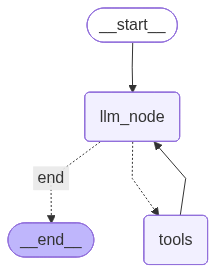

In [26]:
workflow

In [27]:
from langchain_core.messages import HumanMessage
final_state = workflow.invoke({
    "messages": [HumanMessage(content = "Tell me the stock price of GOOG.")]
})

In [28]:
final_state['messages']

[HumanMessage(content='Tell me the stock price of GOOG.', additional_kwargs={}, response_metadata={}, id='7f01ff17-3844-468e-9d31-2ef462a1a112'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'w6z92s52v', 'function': {'arguments': '{"ticker":"GOOG"}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 344, 'total_tokens': 360, 'completion_time': 0.05660085, 'completion_tokens_details': None, 'prompt_time': 0.089361273, 'prompt_tokens_details': None, 'queue_time': 0.183955375, 'total_time': 0.145962123}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9bae-aa40-7223-adfb-bbcf17a23c59-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'GOOG'}, 'id': 'w6z92s52v', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_token